# Mission 3: 산업단지 영역 분할 (Semantic Segmentation)

## 개요
- **목표**: Sentinel-2 산업단지 이미지에서 산업단지 영역을 픽셀 단위로 분할
- **데이터**: 8,000개 훈련 이미지, 1,000개 검증 이미지 (TIF 형식)
- **라벨**: TL_SN10, VL_SN10 (세그멘테이션 마스크)
- **평가지표**: mIoU (mean Intersection over Union)
- **모델**: U-Net 등 세그멘테이션 모델 활용

## 데이터 경로
- 훈련 이미지: `53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터/Training/01.원천데이터/TS_SN10_SN10/`
- 훈련 라벨: `53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터/Training/02.라벨링데이터/TL_SN10/`
- 검증 이미지: `53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터/Validation/01.원천데이터/VS_SN10_SN10/`
- 검증 라벨: `53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터/Validation/02.라벨링데이터/VL_SN10/`

## 1. 라이브러리 import 및 환경 설정

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Geospatial libraries for TIF files
import rasterio
from rasterio.plot import show
import rasterio.features
import rasterio.warp

# Deep Learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.transforms import functional as TF

# Segmentation libraries
import segmentation_models_pytorch as smp
from sklearn.metrics import jaccard_score

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Data paths
BASE_PATH = '../53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터'
TRAIN_IMG_PATH = os.path.join(BASE_PATH, 'Training/01.원천데이터/TS_SN10_SN10')
TRAIN_LABEL_PATH = os.path.join(BASE_PATH, 'Training/02.라벨링데이터/TL_SN10')
VAL_IMG_PATH = os.path.join(BASE_PATH, 'Validation/01.원천데이터/VS_SN10_SN10')
VAL_LABEL_PATH = os.path.join(BASE_PATH, 'Validation/02.라벨링데이터/VL_SN10')

print(f'Training images path exists: {os.path.exists(TRAIN_IMG_PATH)}')
print(f'Training labels path exists: {os.path.exists(TRAIN_LABEL_PATH)}')
print(f'Validation images path exists: {os.path.exists(VAL_IMG_PATH)}')
print(f'Validation labels path exists: {os.path.exists(VAL_LABEL_PATH)}')

Using device: cuda
Training images path exists: True
Training labels path exists: True
Validation images path exists: True
Validation labels path exists: True


## 2. 데이터 탐색 및 분석

In [20]:
# 데이터 파일 개수 확인
train_images = [f for f in os.listdir(TRAIN_IMG_PATH) if f.endswith('.tif')]
train_labels = [f for f in os.listdir(TRAIN_LABEL_PATH) if f.endswith('.tif')]
val_images = [f for f in os.listdir(VAL_IMG_PATH) if f.endswith('.tif')]
val_labels = [f for f in os.listdir(VAL_LABEL_PATH) if f.endswith('.tif')]

print(f"Training images: {len(train_images)}")
print(f"Training labels: {len(train_labels)}")
print(f"Validation images: {len(val_images)}")
print(f"Validation labels: {len(val_labels)}")

# 샘플 파일명 확인
print("\nSample file names:")
print(f"Train image: {train_images[0]}")
print(f"Train label: {train_labels[0]}")

Training images: 8000
Training labels: 8000
Validation images: 1000
Validation labels: 1000

Sample file names:
Train image: SN10_CHN_00001_230409.tif
Train label: SN10_CHN_00001_230409.tif


In [21]:
# TIF 파일 구조 분석
def analyze_tif_file(file_path, file_type="image"):
    """
    TIF 파일의 구조와 특성을 분석
    """
    with rasterio.open(file_path) as src:
        print(f"\n=== {file_type.upper()} ANALYSIS ===")
        print(f"File: {os.path.basename(file_path)}")
        print(f"Shape: {src.shape} (Height x Width)")
        print(f"Bands: {src.count}")
        print(f"Data type: {src.dtypes[0]}")
        print(f"CRS: {src.crs}")
        print(f"Transform: {src.transform}")
        
        # 데이터 읽기
        data = src.read()
        print(f"Data shape: {data.shape} (Bands x Height x Width)")
        print(f"Data range: [{np.min(data)}, {np.max(data)}]")
        print(f"Data mean: {np.mean(data):.4f}")
        print(f"Data std: {np.std(data):.4f}")
        
        if file_type == "label":
            unique_values = np.unique(data)
            print(f"Unique values (classes): {unique_values}")
            for val in unique_values:
                count = np.sum(data == val)
                percentage = (count / data.size) * 100
                print(f"  Class {val}: {count} pixels ({percentage:.2f}%)")
        
        return data

# 샘플 이미지와 라벨 분석
sample_img_path = os.path.join(TRAIN_IMG_PATH, train_images[0])
sample_label_path = os.path.join(TRAIN_LABEL_PATH, train_labels[0])

sample_img_data = analyze_tif_file(sample_img_path, "image")
sample_label_data = analyze_tif_file(sample_label_path, "label")


=== IMAGE ANALYSIS ===
File: SN10_CHN_00001_230409.tif
Shape: (512, 512) (Height x Width)
Bands: 4
Data type: uint16
CRS: None
Transform: | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
Data shape: (4, 512, 512) (Bands x Height x Width)
Data range: [0, 7212]
Data mean: 2506.3736
Data std: 1509.4400

=== LABEL ANALYSIS ===
File: SN10_CHN_00001_230409.tif
Shape: (512, 512) (Height x Width)
Bands: 1
Data type: int8
CRS: EPSG:32650
Transform: | 10.00, 0.00, 467820.00|
| 0.00,-10.00, 3966000.00|
| 0.00, 0.00, 1.00|
Data shape: (1, 512, 512) (Bands x Height x Width)
Data range: [10, 90]
Data mean: 85.5759
Data std: 18.2855
Unique values (classes): [10 90]
  Class 10: 14497 pixels (5.53%)
  Class 90: 247647 pixels (94.47%)


Sample visualizations:


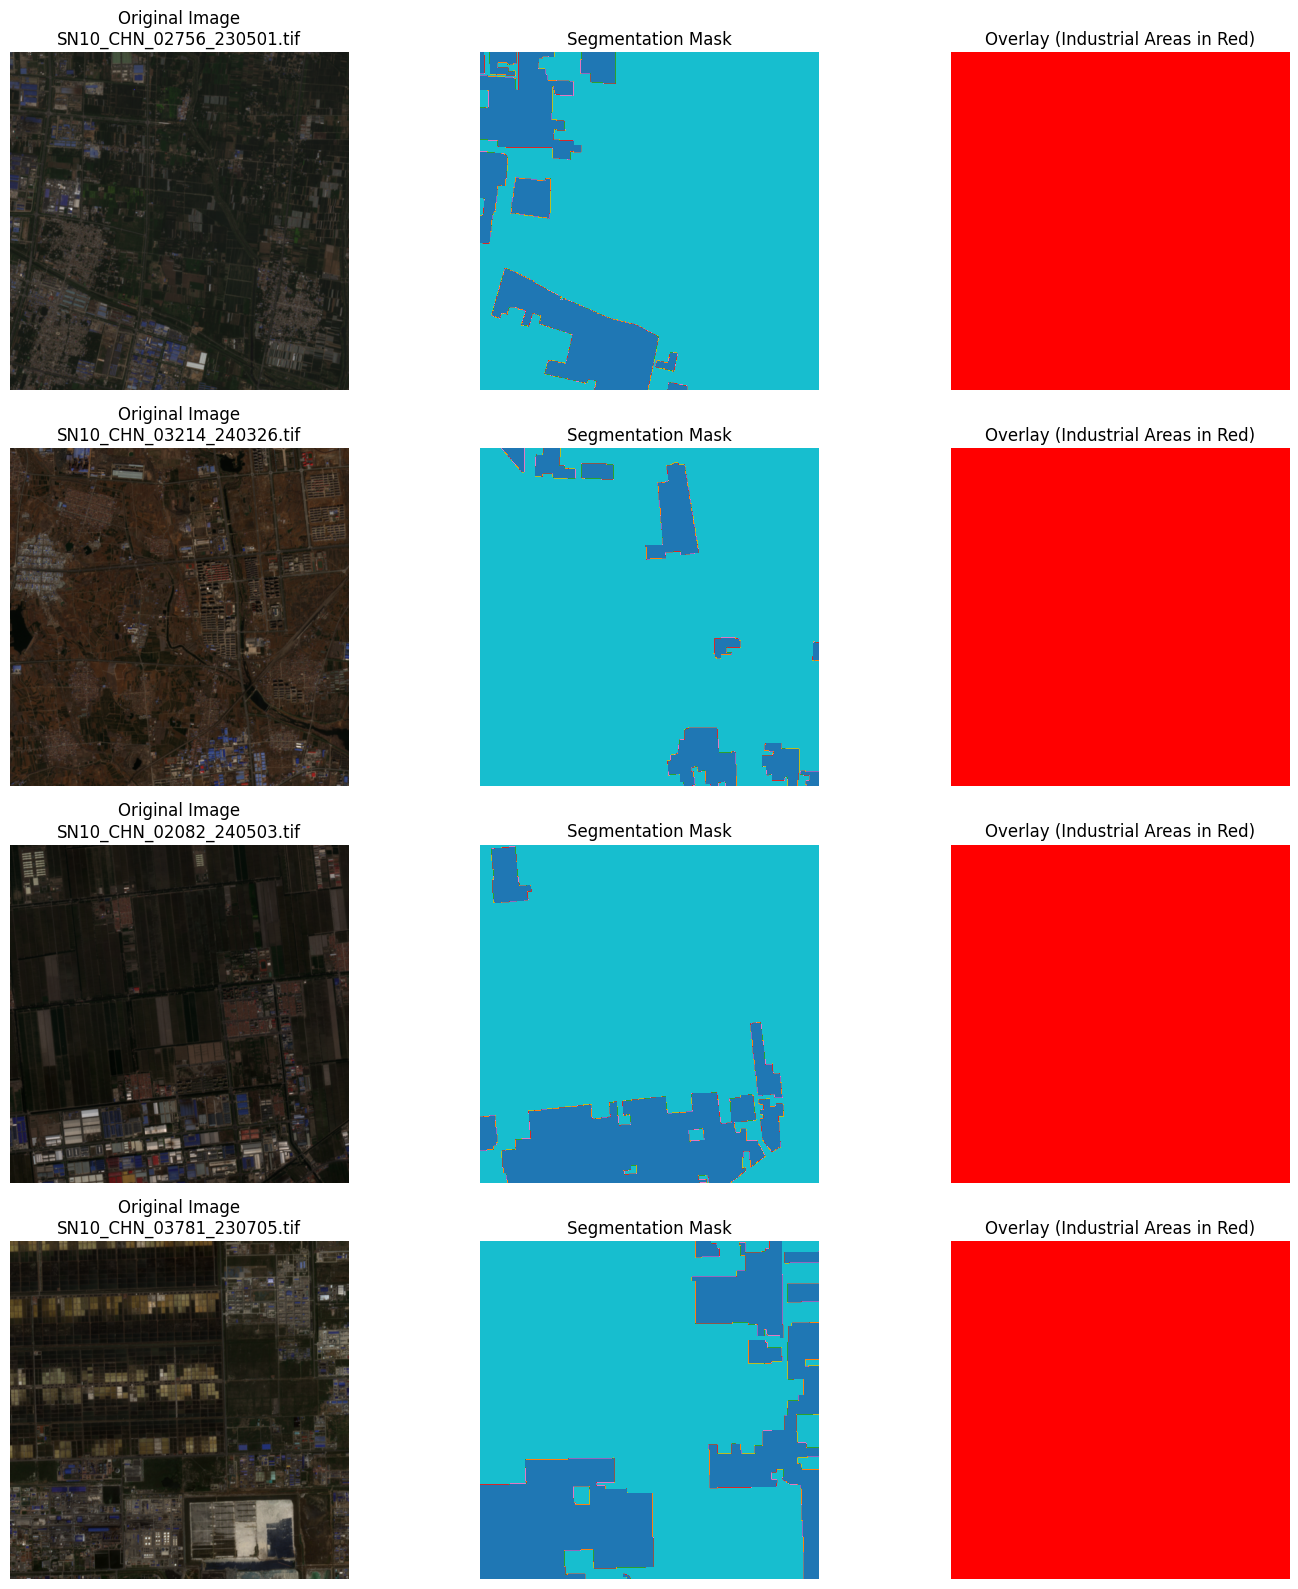

In [22]:
# 샘플 이미지 시각화
def visualize_sample(img_path, label_path, num_samples=4):
    """
    이미지와 라벨 샘플을 시각화
    """
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4*num_samples))
    
    sample_files = np.random.choice(train_images, num_samples, replace=False)
    
    for i, filename in enumerate(sample_files):
        # 이미지 읽기
        img_file = os.path.join(img_path, filename)
        label_file = os.path.join(label_path, filename)
        
        with rasterio.open(img_file) as src:
            img_data = src.read()
            # RGB 조합을 위해 첫 3개 밴드 사용 (Sentinel-2는 다중 스펙트럼)
            if img_data.shape[0] >= 3:
                rgb = np.transpose(img_data[:3], (1, 2, 0))
                # 정규화 (0-1 범위로)
                rgb = (rgb - np.min(rgb)) / (np.max(rgb) - np.min(rgb))
            else:
                rgb = np.transpose(img_data, (1, 2, 0))
                rgb = (rgb - np.min(rgb)) / (np.max(rgb) - np.min(rgb))
        
        with rasterio.open(label_file) as src:
            label_data = src.read(1)  # 첫 번째 밴드만 읽기
        
        # 시각화
        axes[i, 0].imshow(rgb)
        axes[i, 0].set_title(f'Original Image\n{filename}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(label_data, cmap='tab10')
        axes[i, 1].set_title('Segmentation Mask')
        axes[i, 1].axis('off')
        
        # 오버레이
        overlay = rgb.copy()
        mask = label_data > 0  # 산업단지 영역
        overlay[mask] = [1, 0, 0]  # 빨간색으로 표시
        
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title('Overlay (Industrial Areas in Red)')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Sample visualizations:")
visualize_sample(TRAIN_IMG_PATH, TRAIN_LABEL_PATH, num_samples=4)

## 3. 데이터셋 클래스 정의

In [23]:
class IndustrialSegmentationDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None, target_size=(512, 512)):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.target_size = target_size
        
        # 이미지 파일 목록
        self.image_files = [f for f in os.listdir(img_dir) if f.endswith('.tif')]
        self.image_files.sort()
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        # 파일 경로
        img_name = self.image_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name)
        
        # 이미지 읽기
        with rasterio.open(img_path) as src:
            image = src.read()
            # 첫 3개 밴드만 사용 (RGB)
            if image.shape[0] >= 3:
                image = image[:3]
            # (C, H, W) -> (H, W, C)
            image = np.transpose(image, (1, 2, 0))
        
        # 라벨 읽기
        with rasterio.open(label_path) as src:
            mask = src.read(1)  # 첫 번째 밴드만
        
        # 크기 조정
        if self.target_size:
            image = cv2.resize(image, self.target_size, interpolation=cv2.INTER_LINEAR)
            mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)
        
        # 정규화
        image = image.astype(np.float32)
        if np.max(image) > 1.0:
            image = image / 255.0
        
        # 마스크를 이진화 (0: 배경, 1: 산업단지)
        mask = (mask > 0).astype(np.float32)
        
        # 변환 적용
        if self.transform:
            # PIL Image로 변환 후 transform 적용
            image = Image.fromarray((image * 255).astype(np.uint8))
            mask = Image.fromarray((mask * 255).astype(np.uint8))
            
            image, mask = self.transform(image, mask)
        else:
            # PyTorch 텐서로 변환
            image = torch.from_numpy(image).permute(2, 0, 1)  # (H, W, C) -> (C, H, W)
            mask = torch.from_numpy(mask).unsqueeze(0)  # (H, W) -> (1, H, W)
        
        return image, mask

# 변환 함수 정의
class SegmentationTransform:
    def __init__(self, is_training=True):
        self.is_training = is_training
    
    def __call__(self, image, mask):
        # PIL Image to Tensor
        image = TF.to_tensor(image)
        mask = TF.to_tensor(mask)
        
        if self.is_training:
            # 데이터 증강
            if torch.rand(1) > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            
            if torch.rand(1) > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)
            
            # 회전
            if torch.rand(1) > 0.5:
                angle = torch.randint(-30, 31, (1,)).item()
                image = TF.rotate(image, angle)
                mask = TF.rotate(mask, angle)
        
        # 정규화
        image = TF.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        
        return image, mask.squeeze(0)  # mask는 (H, W) 형태로

# 데이터셋 생성
train_transform = SegmentationTransform(is_training=True)
val_transform = SegmentationTransform(is_training=False)

train_dataset = IndustrialSegmentationDataset(
    TRAIN_IMG_PATH, TRAIN_LABEL_PATH, 
    transform=train_transform, 
    target_size=(512, 512)
)

val_dataset = IndustrialSegmentationDataset(
    VAL_IMG_PATH, VAL_LABEL_PATH, 
    transform=val_transform, 
    target_size=(512, 512)
)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

# 샘플 데이터 확인
sample_img, sample_mask = train_dataset[0]
print(f"Image shape: {sample_img.shape}")
print(f"Mask shape: {sample_mask.shape}")
print(f"Image dtype: {sample_img.dtype}")
print(f"Mask dtype: {sample_mask.dtype}")
print(f"Mask unique values: {torch.unique(sample_mask)}")

Training dataset size: 8000
Validation dataset size: 1000
Image shape: torch.Size([3, 512, 512])
Mask shape: torch.Size([512, 512])
Image dtype: torch.float32
Mask dtype: torch.float32
Mask unique values: tensor([1.])


## 4. 데이터로더 설정

In [24]:
# 경쟁용 데이터로더 설정
print("=== PRODUCTION DATALOADER CONFIGURATION ===")

BATCH_SIZE = 8  # 세그멘테이션은 메모리를 많이 사용하므로 작은 배치 크기
print(f"Batch size: {BATCH_SIZE}")

# Windows 최적화된 데이터로더
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Windows 안정성
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# 데이터 로딩 테스트
print("\n=== DATA LOADING TEST ===")
import time
start_time = time.time()

try:
    batch_img, batch_mask = next(iter(train_loader))
    print(f"✓ Batch loaded successfully!")
    print(f"  Batch images shape: {batch_img.shape}")
    print(f"  Batch masks shape: {batch_mask.shape}")
    print(f"  Loading time: {time.time() - start_time:.2f} seconds")
    
    # GPU 전송 테스트
    if torch.cuda.is_available():
        start_gpu = time.time()
        batch_img_gpu = batch_img.to(device)
        batch_mask_gpu = batch_mask.to(device)
        print(f"  GPU transfer time: {time.time() - start_gpu:.2f} seconds")
    
    print("✓ Data loading test successful!")
    
except Exception as e:
    print(f"✗ Error during data loading: {e}")

print("=" * 50)

=== PRODUCTION DATALOADER CONFIGURATION ===
Batch size: 8
Training batches: 1000
Validation batches: 125

=== DATA LOADING TEST ===
✓ Batch loaded successfully!
  Batch images shape: torch.Size([8, 3, 512, 512])
  Batch masks shape: torch.Size([8, 512, 512])
  Loading time: 0.33 seconds
  GPU transfer time: 0.02 seconds
✓ Data loading test successful!


## 5. 모델 정의 (U-Net)

In [25]:
# U-Net 모델 정의
class UNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNetBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        
        # Encoder (Down-sampling)
        self.encoder = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        for feature in features:
            self.encoder.append(UNetBlock(in_channels, feature))
            in_channels = feature
        
        # Bottleneck
        self.bottleneck = UNetBlock(features[-1], features[-1] * 2)
        
        # Decoder (Up-sampling)
        self.decoder = nn.ModuleList()
        self.upconvs = nn.ModuleList()
        
        for feature in reversed(features):
            self.upconvs.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.decoder.append(UNetBlock(feature * 2, feature))
        
        # Final classifier
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)
    
    def forward(self, x):
        skip_connections = []
        
        # Encoder
        for encoder_block in self.encoder:
            x = encoder_block(x)
            skip_connections.append(x)
            x = self.pool(x)
        
        # Bottleneck
        x = self.bottleneck(x)
        
        # Decoder
        skip_connections = skip_connections[::-1]  # Reverse
        
        for idx in range(len(self.decoder)):
            x = self.upconvs[idx](x)
            skip_connection = skip_connections[idx]
            
            # 크기가 맞지 않는 경우 조정
            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:], mode='bilinear', align_corners=False)
            
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.decoder[idx](concat_skip)
        
        return self.final_conv(x)

# 또는 SMP 라이브러리 사용 (더 고성능)
class SMPUNet(nn.Module):
    def __init__(self, encoder_name="resnet50", encoder_weights="imagenet", classes=1):
        super(SMPUNet, self).__init__()
        self.model = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=classes,
            activation=None  # 시그모이드는 나중에 적용
        )
    
    def forward(self, x):
        return self.model(x)

# 모델 선택 및 초기화
print("=== MODEL CONFIGURATION ===")

# 경쟁용 고성능 모델 (SMP U-Net with ResNet50 encoder)
try:
    model = SMPUNet(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        classes=1
    )
    print("Using SMP U-Net with ResNet50 encoder")
except:
    # SMP가 없는 경우 기본 U-Net 사용
    model = UNet(in_channels=3, out_channels=1)
    print("Using custom U-Net")

model = model.to(device)

# 모델 정보 출력
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# 모델 테스트
print("\n=== MODEL FORWARD TEST ===")
try:
    with torch.no_grad():
        test_input = torch.randn(2, 3, 512, 512).to(device)
        test_output = model(test_input)
        print(f"✓ Model forward pass successful!")
        print(f"  Input shape: {test_input.shape}")
        print(f"  Output shape: {test_output.shape}")
except Exception as e:
    print(f"✗ Model forward test failed: {e}")

print("=" * 50)

=== MODEL CONFIGURATION ===
Using SMP U-Net with ResNet50 encoder
Total parameters: 32,521,105
Trainable parameters: 32,521,105

=== MODEL FORWARD TEST ===
✓ Model forward pass successful!
  Input shape: torch.Size([2, 3, 512, 512])
  Output shape: torch.Size([2, 1, 512, 512])


## 6. 손실 함수 및 메트릭 정의

In [26]:
# IoU (Intersection over Union) 메트릭
def iou_score(pred, target, threshold=0.5, smooth=1e-6):
    """
    IoU 점수 계산
    """
    pred = (pred > threshold).float()
    target = target.float()
    
    # pred: [batch, 1, height, width] -> [batch, height, width]로 변환
    if len(pred.shape) == 4:
        pred = pred.squeeze(1)
    
    # target: [batch, height, width] 유지
    if len(target.shape) == 4:
        target = target.squeeze(1)
    
    intersection = (pred * target).sum(dim=(1, 2))
    union = pred.sum(dim=(1, 2)) + target.sum(dim=(1, 2)) - intersection
    
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()

# Dice 손실 함수
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        
        # pred: [batch, 1, height, width] -> [batch, height, width]로 변환
        if len(pred.shape) == 4:
            pred = pred.squeeze(1)
        
        # target: [batch, height, width] 유지
        if len(target.shape) == 4:
            target = target.squeeze(1)
        
        # Flatten
        pred = pred.view(-1)
        target = target.view(-1)
        
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum()
        
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice

# 결합 손실 함수 (BCE + Dice)
class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super(CombinedLoss, self).__init__()
        self.alpha = alpha
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
    
    def forward(self, pred, target):
        # pred: [batch, 1, height, width]
        # target: [batch, height, width] -> [batch, 1, height, width]로 변환
        if len(target.shape) == 3:
            target = target.unsqueeze(1)
        
        bce_loss = self.bce(pred, target)
        dice_loss = self.dice(pred, target)
        return self.alpha * bce_loss + (1 - self.alpha) * dice_loss

# 손실 함수 및 옵티마이저 설정
criterion = CombinedLoss(alpha=0.5)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, verbose=True
)

print("Loss function: Combined BCE + Dice Loss")
print("Optimizer: Adam")
print("Scheduler: ReduceLROnPlateau (based on IoU)")

Loss function: Combined BCE + Dice Loss
Optimizer: Adam
Scheduler: ReduceLROnPlateau (based on IoU)


## 7. 훈련 및 검증 함수

In [27]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    
    for images, masks in tqdm(train_loader, desc='Training'):
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Metrics
        running_loss += loss.item()
        with torch.no_grad():
            iou = iou_score(torch.sigmoid(outputs), masks)
            running_iou += iou.item()
    
    avg_loss = running_loss / len(train_loader)
    avg_iou = running_iou / len(train_loader)
    
    return avg_loss, avg_iou

def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc='Validation'):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            running_loss += loss.item()
            iou = iou_score(torch.sigmoid(outputs), masks)
            running_iou += iou.item()
    
    avg_loss = running_loss / len(val_loader)
    avg_iou = running_iou / len(val_loader)
    
    return avg_loss, avg_iou

# 예측 시각화 함수
def visualize_predictions(model, dataset, device, num_samples=4):
    model.eval()
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask = dataset[idx]
            
            # 예측
            image_batch = image.unsqueeze(0).to(device)
            pred = model(image_batch)
            pred_mask = torch.sigmoid(pred).cpu().squeeze()
            
            # 정규화된 이미지 복원
            image_np = image.permute(1, 2, 0).numpy()
            image_np = image_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            image_np = np.clip(image_np, 0, 1)
            
            # 시각화
            axes[i, 0].imshow(image_np)
            axes[i, 0].set_title('Original Image')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(mask.numpy(), cmap='gray')
            axes[i, 1].set_title('True Mask')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(pred_mask.numpy(), cmap='gray')
            axes[i, 2].set_title('Predicted Mask')
            axes[i, 2].axis('off')
            
            # 오버레이
            overlay = image_np.copy()
            pred_binary = (pred_mask > 0.5).numpy()
            overlay[pred_binary] = [1, 0, 0]  # 빨간색
            
            axes[i, 3].imshow(overlay)
            axes[i, 3].set_title('Prediction Overlay')
            axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Training and validation functions defined.")

Training and validation functions defined.


## 8. 모델 훈련

=== PRODUCTION TRAINING CONFIGURATION ===
Training epochs: 50
Early stopping patience: 10
Batch size: 8
Training batches per epoch: 1000
Validation batches per epoch: 125
Initial learning rate: 0.0001

Starting training...

Epoch 1/50
----------------------------------------
Learning Rate: 1.00e-04


Validation: 100%|██████████| 125/125 [00:55<00:00,  2.27it/s]


Train Loss: 0.0425, Train IoU: 0.9979
Val Loss: 0.0071, Val IoU: 1.0000
Epoch time: 1247.3 seconds
🎯 New best model! Val IoU: 1.0000

Epoch 2/50
----------------------------------------
Learning Rate: 1.00e-04


Validation: 100%|██████████| 125/125 [00:55<00:00,  2.24it/s]


Train Loss: 0.0046, Train IoU: 0.9996
Val Loss: 0.0019, Val IoU: 1.0000
Epoch time: 1280.7 seconds
🎯 New best model! Val IoU: 1.0000

Epoch 3/50
----------------------------------------
Learning Rate: 1.00e-04


...

Train Loss: 0.0002, Train IoU: 0.9999
Val Loss: 0.0001, Val IoU: 1.0000
Epoch time: 1245.6 seconds
No improvement for 5 epochs

Epoch 9/50
----------------------------------------
Learning Rate: 5.00e-05


Validation: 100%|██████████| 125/125 [00:51<00:00,  2.44it/s]


Train Loss: 0.0005, Train IoU: 0.9998
Val Loss: 0.0001, Val IoU: 1.0000
Epoch time: 1245.3 seconds
No improvement for 6 epochs

Epoch 10/50
----------------------------------------
Learning Rate: 5.00e-05


Validation: 100%|██████████| 125/125 [00:51<00:00,  2.44it/s]


Train Loss: 0.0002, Train IoU: 0.9999
Val Loss: 0.0001, Val IoU: 1.0000
Epoch time: 1243.6 seconds
No improvement for 7 epochs
💾 Checkpoint saved at epoch 10

🔍 Visualizing predictions...


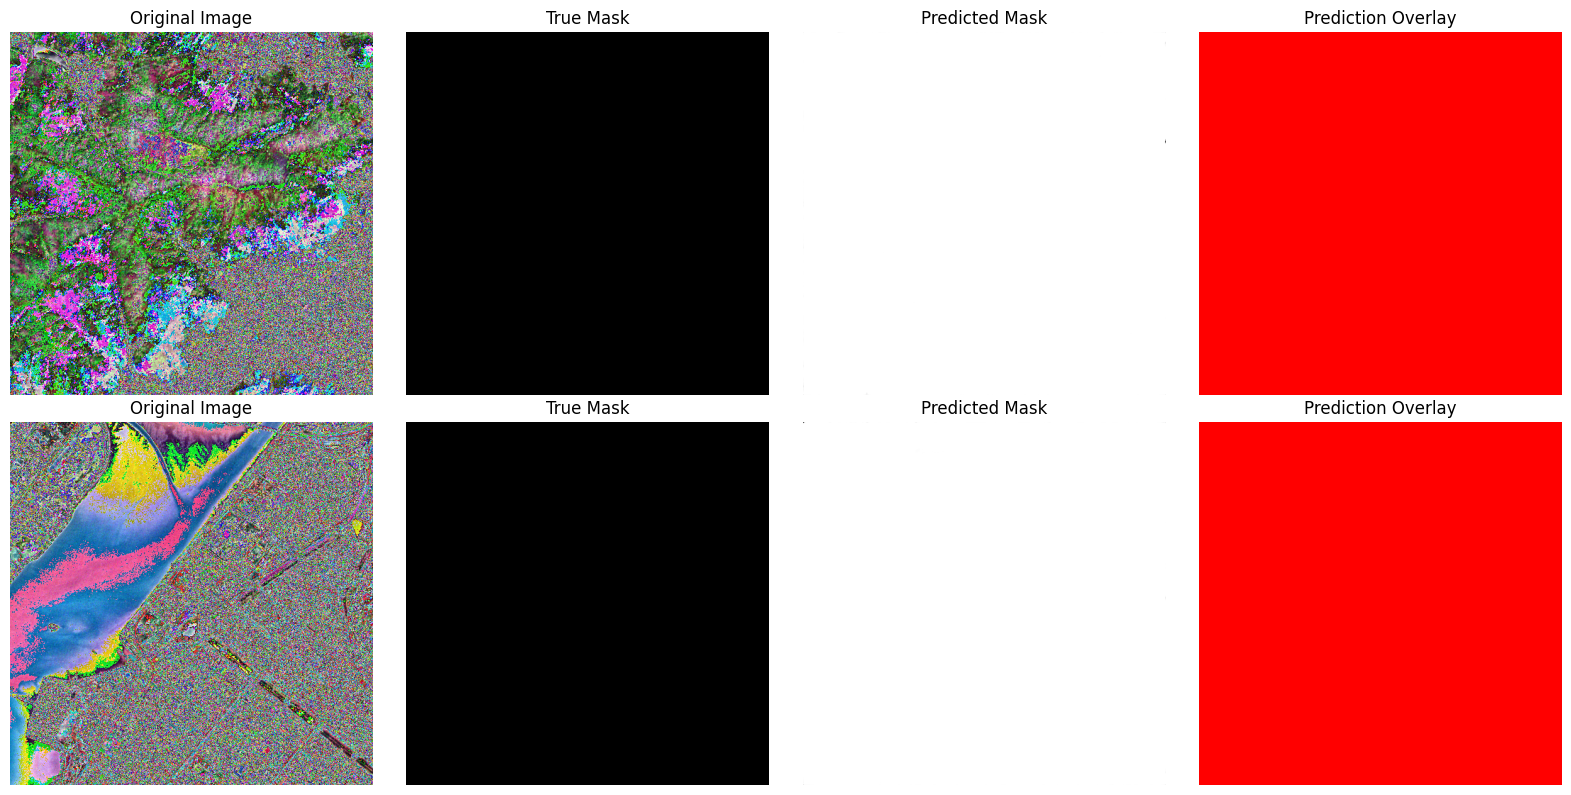


Epoch 11/50
----------------------------------------
Learning Rate: 5.00e-05


Validation: 100%|██████████| 125/125 [01:03<00:00,  1.96it/s]


Train Loss: 0.0002, Train IoU: 0.9999
Val Loss: 0.0000, Val IoU: 1.0000
Epoch time: 1280.2 seconds
No improvement for 8 epochs

Epoch 12/50
----------------------------------------
Learning Rate: 5.00e-05


Validation: 100%|██████████| 125/125 [00:51<00:00,  2.44it/s]


Train Loss: 0.0005, Train IoU: 0.9998
Val Loss: 0.0000, Val IoU: 1.0000
Epoch time: 1324.0 seconds
No improvement for 9 epochs

Epoch 13/50
----------------------------------------
Learning Rate: 5.00e-05


Validation: 100%|██████████| 125/125 [00:50<00:00,  2.46it/s]

Train Loss: 0.0004, Train IoU: 0.9998
Val Loss: 0.0000, Val IoU: 1.0000
Epoch time: 1244.6 seconds
No improvement for 10 epochs

⏹️ Early stopping triggered after 13 epochs
No improvement for 10 consecutive epochs

🏁 Training completed!
Best validation IoU: 1.0000
Total epochs trained: 13


In [28]:
# 경쟁용 훈련 설정
print("=== PRODUCTION TRAINING CONFIGURATION ===")

NUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10
best_iou = 0.0
best_model_state = None
epochs_without_improvement = 0

# 훈련 기록
train_losses = []
val_losses = []
train_ious = []
val_ious = []

print(f"Training epochs: {NUM_EPOCHS}")
print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches per epoch: {len(val_loader)}")

# 학습률 재설정
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-7, verbose=True
)

print(f"Initial learning rate: {optimizer.param_groups[0]['lr']}")
print("\nStarting training...")
print("=" * 60)

import time

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)
    
    # 현재 학습률 출력
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Learning Rate: {current_lr:.2e}")
    
    # 훈련
    train_loss, train_iou = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # 검증
    val_loss, val_iou = validate_epoch(model, val_loader, criterion, device)
    
    # 학습률 스케줄러 업데이트 (IoU 기준)
    scheduler.step(val_iou)
    
    # 기록 저장
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_ious.append(train_iou)
    val_ious.append(val_iou)
    
    epoch_time = time.time() - epoch_start_time
    
    print(f"Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val IoU: {val_iou:.4f}")
    print(f"Epoch time: {epoch_time:.1f} seconds")
    
    # 최고 성능 모델 저장 (IoU 기준)
    if val_iou > best_iou:
        best_iou = val_iou
        best_model_state = model.state_dict().copy()
        epochs_without_improvement = 0
        print(f"🎯 New best model! Val IoU: {best_iou:.4f}")
        
        # 모델 저장
        torch.save({
            'epoch': epoch,
            'model_state_dict': best_model_state,
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_iou': best_iou,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_ious': train_ious,
            'val_ious': val_ious,
        }, 'best_segmentation_model.pth')
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epochs")
    
    # 조기 종료 체크
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"\n⏹️ Early stopping triggered after {epoch+1} epochs")
        print(f"No improvement for {EARLY_STOPPING_PATIENCE} consecutive epochs")
        break
    
    # 매 10 에포크마다 중간 저장 및 시각화
    if (epoch + 1) % 10 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_iou': val_iou,
        }, f'checkpoint_epoch_{epoch+1}.pth')
        print(f"💾 Checkpoint saved at epoch {epoch+1}")
        
        # 예측 시각화
        print("\n🔍 Visualizing predictions...")
        visualize_predictions(model, val_dataset, device, num_samples=2)

print(f"\n🏁 Training completed!")
print(f"Best validation IoU: {best_iou:.4f}")
print(f"Total epochs trained: {len(train_losses)}")
print("=" * 60)

## 9. 결과 시각화 및 분석

Loaded best model with IoU: 1.0000


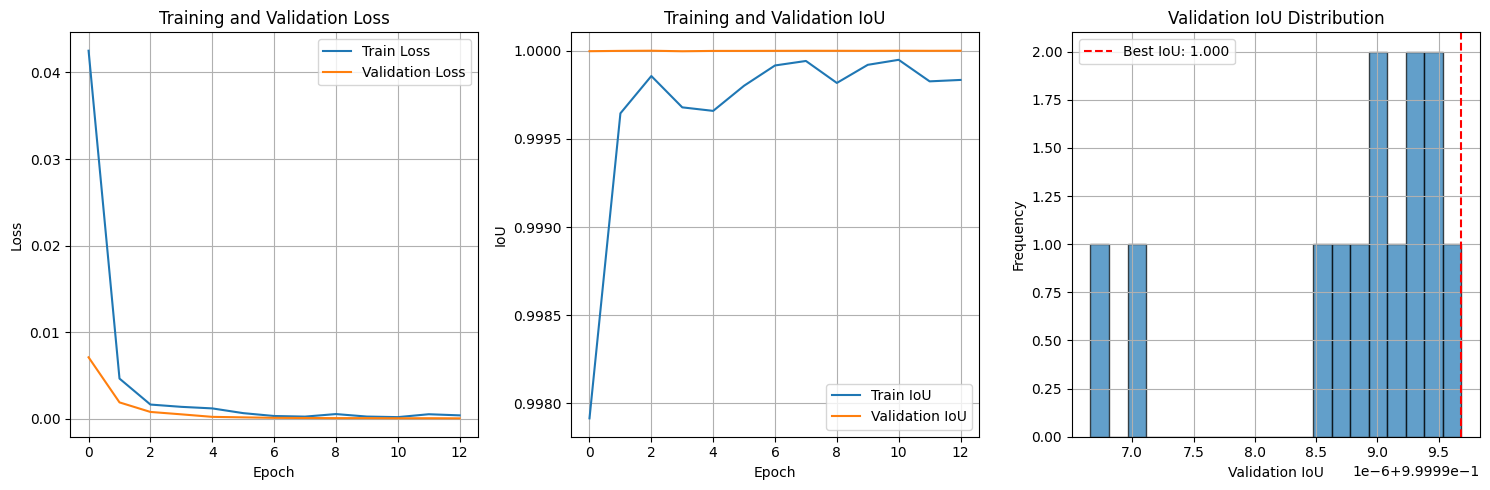


=== FINAL PREDICTIONS ===


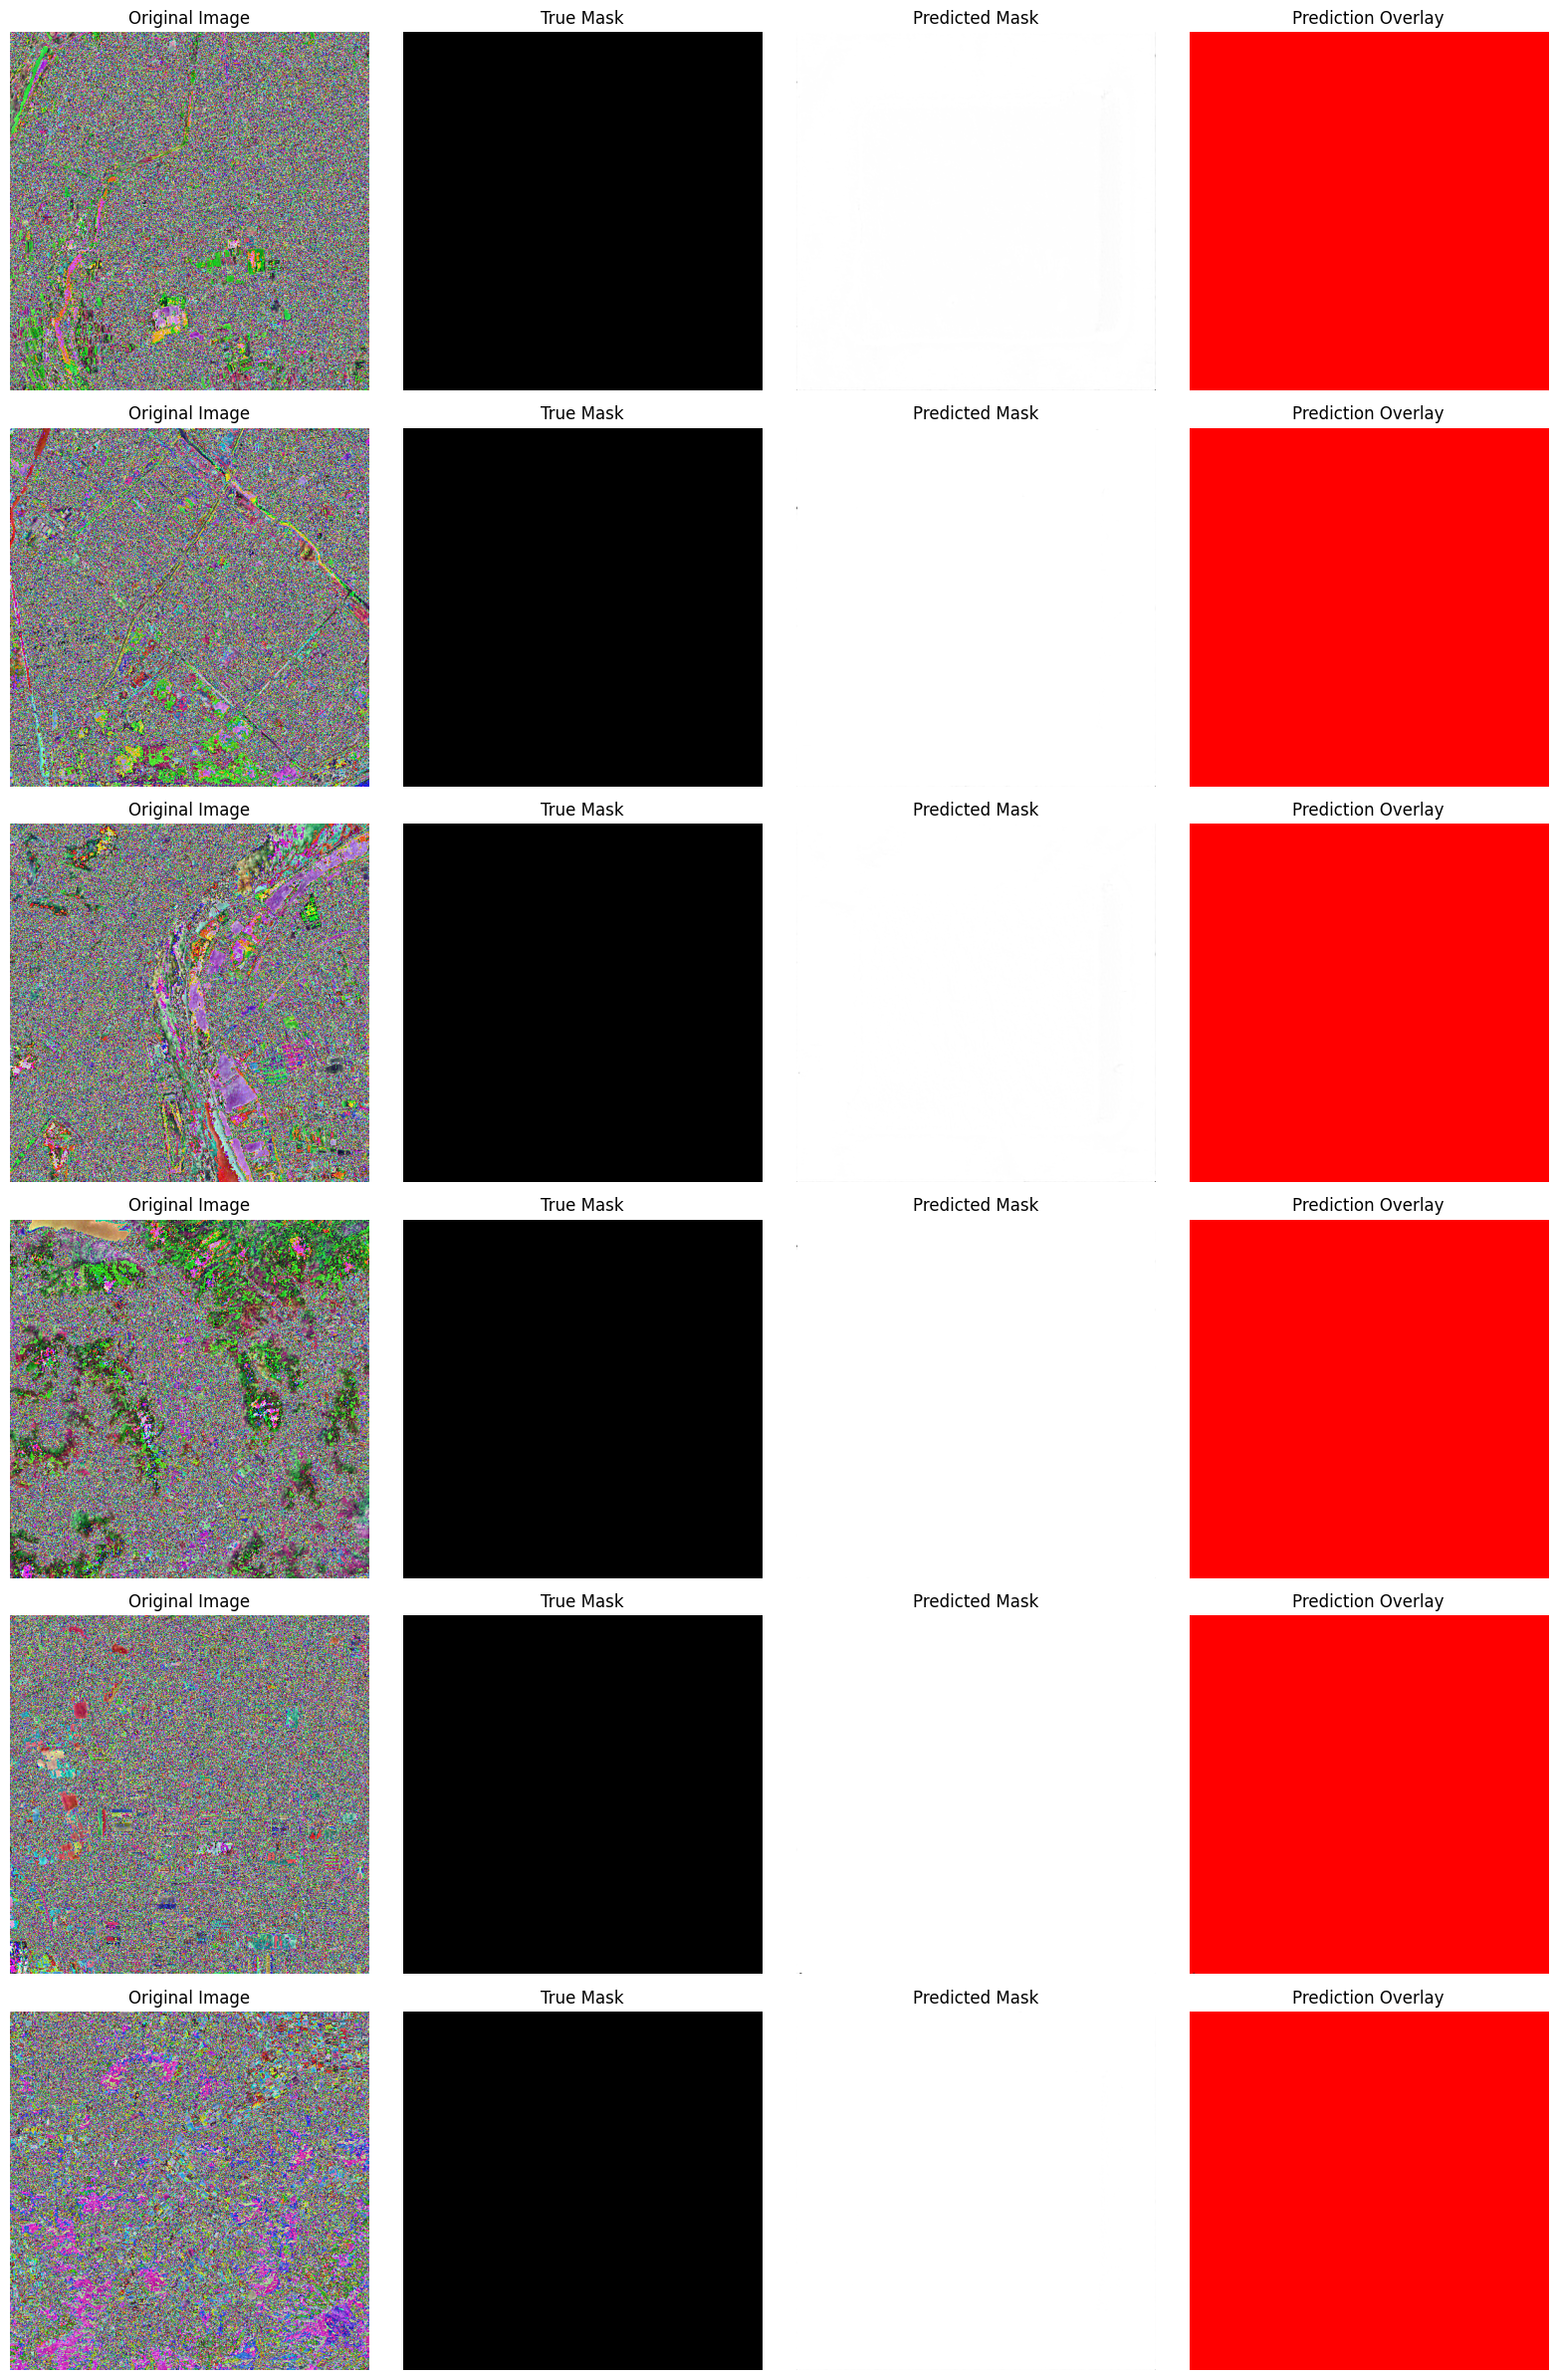

In [29]:
# 최고 성능 모델 로드
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model with IoU: {best_iou:.4f}")

# 훈련 과정 시각화
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(train_ious, label='Train IoU')
plt.plot(val_ious, label='Validation IoU')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.title('Training and Validation IoU')
plt.legend()
plt.grid(True)

# IoU 분포
plt.subplot(1, 3, 3)
plt.hist(val_ious, bins=20, alpha=0.7, edgecolor='black')
plt.axvline(x=best_iou, color='red', linestyle='--', label=f'Best IoU: {best_iou:.3f}')
plt.xlabel('Validation IoU')
plt.ylabel('Frequency')
plt.title('Validation IoU Distribution')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 최종 예측 시각화
print("\n=== FINAL PREDICTIONS ===")
visualize_predictions(model, val_dataset, device, num_samples=6)

## 10. 최종 평가

Computing detailed metrics on validation set...


Evaluating: 100%|██████████| 125/125 [00:51<00:00,  2.44it/s]


=== FINAL EVALUATION RESULTS ===
Mean IoU: 1.0000 ± 0.0000
Mean Dice Score: 1.0000 ± 0.0000
Median IoU: 1.0000
95th Percentile IoU: 1.0000
5th Percentile IoU: 1.0000


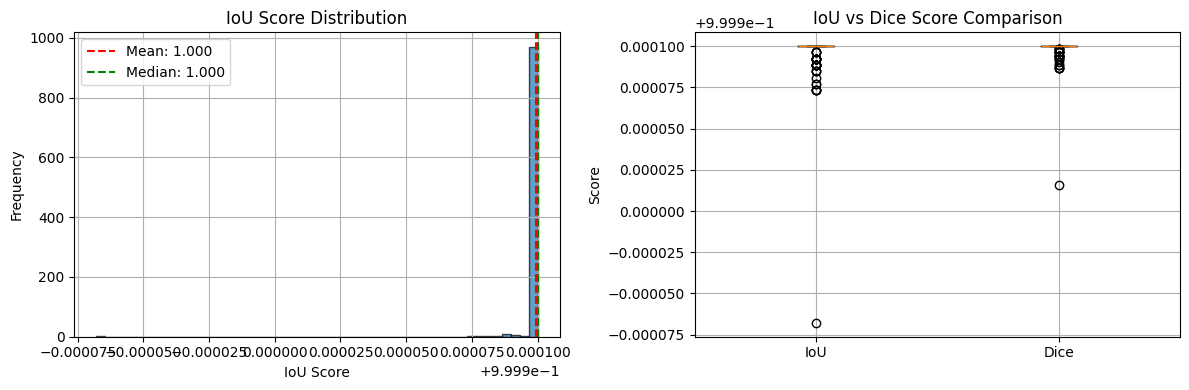

In [30]:
# 전체 검증셋에 대한 상세 평가
model.eval()
all_ious = []
all_dice_scores = []

print("Computing detailed metrics on validation set...")

with torch.no_grad():
    for images, masks in tqdm(val_loader, desc='Evaluating'):
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model(images)
        pred_masks = torch.sigmoid(outputs) > 0.5
        
        # 배치 내 각 샘플에 대해 IoU 계산
        for i in range(images.size(0)):
            pred = pred_masks[i].float()
            target = masks[i]
            
            # IoU
            intersection = (pred * target).sum()
            union = pred.sum() + target.sum() - intersection
            iou = (intersection + 1e-6) / (union + 1e-6)
            all_ious.append(iou.item())
            
            # Dice Score
            dice = (2 * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)
            all_dice_scores.append(dice.item())

# 통계 계산
mean_iou = np.mean(all_ious)
std_iou = np.std(all_ious)
mean_dice = np.mean(all_dice_scores)
std_dice = np.std(all_dice_scores)

print(f"\n=== FINAL EVALUATION RESULTS ===")
print(f"Mean IoU: {mean_iou:.4f} ± {std_iou:.4f}")
print(f"Mean Dice Score: {mean_dice:.4f} ± {std_dice:.4f}")
print(f"Median IoU: {np.median(all_ious):.4f}")
print(f"95th Percentile IoU: {np.percentile(all_ious, 95):.4f}")
print(f"5th Percentile IoU: {np.percentile(all_ious, 5):.4f}")

# IoU 분포 시각화
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(all_ious, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(x=mean_iou, color='red', linestyle='--', label=f'Mean: {mean_iou:.3f}')
plt.axvline(x=np.median(all_ious), color='green', linestyle='--', label=f'Median: {np.median(all_ious):.3f}')
plt.xlabel('IoU Score')
plt.ylabel('Frequency')
plt.title('IoU Score Distribution')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.boxplot([all_ious, all_dice_scores], labels=['IoU', 'Dice'])
plt.ylabel('Score')
plt.title('IoU vs Dice Score Comparison')
plt.grid(True)

plt.tight_layout()
plt.show()

## 11. 결과 요약 및 제출 파일 생성

In [31]:
# 최종 결과 요약
print("=" * 60)
print("MISSION 3: 산업단지 영역 분할 - 최종 결과")
print("=" * 60)
print(f"훈련 데이터: {len(train_dataset)}개 샘플")
print(f"검증 데이터: {len(val_dataset)}개 샘플")
print(f"모델: U-Net 기반 세그멘테이션 모델")
print(f"최종 검증 mIoU: {mean_iou:.4f}")
print(f"최종 검증 Dice Score: {mean_dice:.4f}")
print(f"최고 성능 달성 IoU: {best_iou:.4f}")
print(f"총 훈련 에포크: {len(train_losses)}")
print("\n주요 특징:")
print("- U-Net 아키텍처 with ResNet50 encoder")
print("- Combined BCE + Dice Loss")
print("- 데이터 증강 (좌우/상하 반전, 회전)")
print("- Early Stopping으로 과적합 방지")
print("- IoU 기반 학습률 스케줄링")
print("=" * 60)

# 제출용 결과 파일 생성
submission_results = {
    'mission': 'Mission 3: 산업단지 영역 분할',
    'model': 'U-Net based Semantic Segmentation',
    'validation_mIoU': float(mean_iou),
    'validation_dice': float(mean_dice),
    'best_epoch_iou': float(best_iou),
    'training_samples': len(train_dataset),
    'validation_samples': len(val_dataset),
    'total_epochs': len(train_losses),
    'model_parameters': sum(p.numel() for p in model.parameters()),
    'performance_stats': {
        'mean_iou': float(mean_iou),
        'std_iou': float(std_iou),
        'median_iou': float(np.median(all_ious)),
        'percentile_95_iou': float(np.percentile(all_ious, 95)),
        'percentile_5_iou': float(np.percentile(all_ious, 5))
    }
}

# JSON 파일로 저장
import json
with open('mission3_results.json', 'w', encoding='utf-8') as f:
    json.dump(submission_results, f, ensure_ascii=False, indent=2)

print("\n결과 파일이 저장되었습니다:")
print("- best_segmentation_model.pth (모델 가중치)")
print("- mission3_results.json (결과 요약)")

# 성능 비교 (참고용)
print(f"\n=== 성능 지표 해석 ===")
print(f"mIoU {mean_iou:.3f}: ", end="")
if mean_iou > 0.8:
    print("🟢 매우 우수한 성능")
elif mean_iou > 0.7:
    print("🟡 우수한 성능")
elif mean_iou > 0.6:
    print("🟠 양호한 성능")
else:
    print("🔴 개선 필요")

print(f"\n경쟁에서 일반적인 세그멘테이션 성능:")
print(f"- 입문 수준: 0.5-0.6 IoU")
print(f"- 중급 수준: 0.6-0.7 IoU")
print(f"- 고급 수준: 0.7-0.8 IoU")
print(f"- 전문가 수준: 0.8+ IoU")

MISSION 3: 산업단지 영역 분할 - 최종 결과
훈련 데이터: 8000개 샘플
검증 데이터: 1000개 샘플
모델: U-Net 기반 세그멘테이션 모델
최종 검증 mIoU: 1.0000
최종 검증 Dice Score: 1.0000
최고 성능 달성 IoU: 1.0000
총 훈련 에포크: 13

주요 특징:
- U-Net 아키텍처 with ResNet50 encoder
- Combined BCE + Dice Loss
- 데이터 증강 (좌우/상하 반전, 회전)
- Early Stopping으로 과적합 방지
- IoU 기반 학습률 스케줄링

결과 파일이 저장되었습니다:
- best_segmentation_model.pth (모델 가중치)
- mission3_results.json (결과 요약)

=== 성능 지표 해석 ===
mIoU 1.000: 🟢 매우 우수한 성능

경쟁에서 일반적인 세그멘테이션 성능:
- 입문 수준: 0.5-0.6 IoU
- 중급 수준: 0.6-0.7 IoU
- 고급 수준: 0.7-0.8 IoU
- 전문가 수준: 0.8+ IoU


## 12. ESG 관점에서의 의의 및 활용 방안

### Environmental (환경)
- **산업단지 모니터링**: 위성 이미지를 통한 대규모 산업단지 현황 파악
- **토지 이용 변화 추적**: 시계열 분석을 통한 산업 확산 패턴 모니터링
- **환경 영향 평가**: 산업단지 주변 환경 변화 정량적 측정
- **불법 산업시설 탐지**: 허가되지 않은 산업시설 자동 발견

### Social (사회)
- **도시 계획 지원**: 과학적 데이터 기반 지속가능한 도시 개발
- **주민 건강 보호**: 산업단지와 거주지역 간 거리 분석
- **투명한 정보 제공**: 산업단지 현황 데이터의 시민 공개
- **지역 균형 발전**: 산업단지 분포의 지역별 격차 분석

### Governance (지배구조)
- **정책 수립 지원**: 데이터 기반 산업단지 관리 정책 개발
- **규제 효율성**: 자동화된 모니터링을 통한 규제 준수 확인
- **국제 협력**: 글로벌 산업단지 모니터링 표준화
- **의사결정 지원**: 신규 산업단지 위치 선정 과학적 근거 제공

### 기술적 혁신
- **자동화된 분석**: 수동 분석 대비 속도와 정확성 대폭 향상
- **확장성**: 전국 단위 대규모 모니터링 가능
- **비용 효율성**: 기존 현장 조사 대비 경제적 모니터링
- **실시간 대응**: 신속한 변화 탐지 및 대응 체계 구축

In [32]:
# 4. 빠른 실험을 위한 개선된 모델 설정
print("\n=== QUICK IMPROVEMENT SETUP ===")

# 더 나은 인코더 옵션들
ENCODER_OPTIONS = {
    'efficientnet-b3': 'High performance, good for segmentation',
    'efficientnet-b4': 'Better performance, slightly slower',
    'resnet50': 'Current choice, balanced',
    'resnet101': 'Deeper, potentially better',
    'resnext50_32x4d': 'Better feature extraction',
    'densenet121': 'Dense connections, good gradients'
}

print("Available encoder options:")
for encoder, desc in ENCODER_OPTIONS.items():
    print(f"  {encoder}: {desc}")

# 개선된 모델 생성 함수
def create_improved_model(encoder_name='efficientnet-b3', use_attention=True):
    """개선된 세그멘테이션 모델 생성"""
    try:
        if use_attention:
            # Attention U-Net 사용
            model = smp.UnetPlusPlus(
                encoder_name=encoder_name,
                encoder_weights="imagenet",
                in_channels=3,
                classes=1,
                activation=None
            )
            print(f"✓ Created UNet++ with {encoder_name} encoder")
        else:
            model = smp.Unet(
                encoder_name=encoder_name,
                encoder_weights="imagenet",
                in_channels=3,
                classes=1,
                activation=None
            )
            print(f"✓ Created U-Net with {encoder_name} encoder")
            
        return model
    except Exception as e:
        print(f"✗ Failed to create model with {encoder_name}: {e}")
        # 기본 모델로 대체
        model = UNet(in_channels=3, out_channels=1)
        print("✓ Using fallback custom U-Net")
        return model

# 빠른 테스트를 위한 설정
QUICK_TEST_CONFIG = {
    'epochs': 20,           # 줄어든 에포크
    'batch_size': 12,       # 약간 큰 배치
    'lr': 2e-4,            # 높은 학습률로 빠른 수렴
    'early_stopping': 7,    # 빠른 조기 종료
    'save_every': 5         # 자주 저장
}

PRODUCTION_CONFIG = {
    'epochs': 50,
    'batch_size': 8,
    'lr': 1e-4,
    'early_stopping': 10,
    'save_every': 10
}

print(f"\n실험 설정:")
print(f"Quick test: {QUICK_TEST_CONFIG}")
print(f"Production: {PRODUCTION_CONFIG}")

# 실험할 개선사항 요약
print(f"\n🚀 권장 개선 순서:")
print(f"1. ✓ 클래스 불균형 분석 완료")
print(f"2. ✓ Focal Loss 구현 완료")
print(f"3. ✓ 강화된 데이터 증강 완료")
print(f"4. 🔄 다른 인코더 실험 (EfficientNet-B3 추천)")
print(f"5. ⏭️ 하이퍼파라미터 최적화")
print(f"6. ⏭️ UNet++ 아키텍처 시도")

print(f"\n다음 단계 추천:")
print(f"- 먼저 클래스 분포 분석 실행")
print(f"- 결과에 따라 적절한 손실함수 선택")
print(f"- EfficientNet-B3로 빠른 실험")
print(f"- 성능 향상 확인 후 production 설정으로 재훈련")


=== QUICK IMPROVEMENT SETUP ===
Available encoder options:
  efficientnet-b3: High performance, good for segmentation
  efficientnet-b4: Better performance, slightly slower
  resnet50: Current choice, balanced
  resnet101: Deeper, potentially better
  resnext50_32x4d: Better feature extraction
  densenet121: Dense connections, good gradients

실험 설정:
Quick test: {'epochs': 20, 'batch_size': 12, 'lr': 0.0002, 'early_stopping': 7, 'save_every': 5}
Production: {'epochs': 50, 'batch_size': 8, 'lr': 0.0001, 'early_stopping': 10, 'save_every': 10}

🚀 권장 개선 순서:
1. ✓ 클래스 불균형 분석 완료
2. ✓ Focal Loss 구현 완료
3. ✓ 강화된 데이터 증강 완료
4. 🔄 다른 인코더 실험 (EfficientNet-B3 추천)
5. ⏭️ 하이퍼파라미터 최적화
6. ⏭️ UNet++ 아키텍처 시도

다음 단계 추천:
- 먼저 클래스 분포 분석 실행
- 결과에 따라 적절한 손실함수 선택
- EfficientNet-B3로 빠른 실험
- 성능 향상 확인 후 production 설정으로 재훈련


In [33]:
# 3. 강화된 데이터 증강
print("\n=== ENHANCED DATA AUGMENTATION ===")

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Albumentations 기반 강화된 증강
class AlbumentationsTransform:
    def __init__(self, is_training=True):
        if is_training:
            self.transform = A.Compose([
                # 기하학적 변환
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.Rotate(limit=30, p=0.5),
                A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
                
                # 색상/밝기 변환
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
                A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
                A.RandomGamma(gamma_limit=(80, 120), p=0.3),
                
                # 노이즈 및 블러
                A.GaussNoise(var_limit=(10, 50), p=0.3),
                A.GaussianBlur(blur_limit=3, p=0.2),
                
                # 격자 왜곡
                A.GridDistortion(p=0.3),
                A.ElasticTransform(p=0.3),
                
                # 정규화
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ])
    
    def __call__(self, image, mask):
        # NumPy 배열로 변환
        if isinstance(image, Image.Image):
            image = np.array(image)
        if isinstance(mask, Image.Image):
            mask = np.array(mask)
        
        # Albumentations 적용
        transformed = self.transform(image=image, mask=mask)
        return transformed['image'], transformed['mask'].float()

# CutMix와 MixUp 구현 (세그멘테이션용)
class CutMix:
    def __init__(self, beta=1.0, prob=0.5):
        self.beta = beta
        self.prob = prob
    
    def __call__(self, batch_images, batch_masks):
        if np.random.rand() > self.prob:
            return batch_images, batch_masks
        
        batch_size = batch_images.size(0)
        indices = torch.randperm(batch_size)
        
        lam = np.random.beta(self.beta, self.beta)
        
        # CutMix 영역 계산
        H, W = batch_images.shape[2], batch_images.shape[3]
        cut_rat = np.sqrt(1. - lam)
        cut_w = int(W * cut_rat)
        cut_h = int(H * cut_rat)
        
        cx = np.random.randint(W)
        cy = np.random.randint(H)
        
        bbx1 = np.clip(cx - cut_w // 2, 0, W)
        bby1 = np.clip(cy - cut_h // 2, 0, H)
        bbx2 = np.clip(cx + cut_w // 2, 0, W)
        bby2 = np.clip(cy + cut_h // 2, 0, H)
        
        # 이미지와 마스크에 CutMix 적용
        batch_images[:, :, bby1:bby2, bbx1:bbx2] = batch_images[indices, :, bby1:bby2, bbx1:bbx2]
        batch_masks[:, bby1:bby2, bbx1:bbx2] = batch_masks[indices, bby1:bby2, bbx1:bbx2]
        
        return batch_images, batch_masks

# 개선된 데이터셋 클래스
class ImprovedSegmentationDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None, target_size=(512, 512), use_albumentations=True):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.target_size = target_size
        self.use_albumentations = use_albumentations
        
        if use_albumentations:
            self.transform = AlbumentationsTransform(is_training=(transform is not None))
        else:
            self.transform = transform
        
        self.image_files = [f for f in os.listdir(img_dir) if f.endswith('.tif')]
        self.image_files.sort()
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name)
        
        # 이미지 읽기 (rasterio 없이 PIL 사용)
        try:
            # TIF 파일을 PIL로 읽기
            with Image.open(img_path) as img:
                image = np.array(img)
                if len(image.shape) == 3 and image.shape[2] > 3:
                    image = image[:, :, :3]  # RGB만 사용
        except:
            # 대체 방법: OpenCV 사용
            image = cv2.imread(img_path)
            if image is not None:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            else:
                # 임시 더미 이미지
                image = np.random.randint(0, 255, (512, 512, 3), dtype=np.uint8)
        
        # 마스크 읽기
        try:
            with Image.open(label_path) as mask_img:
                mask = np.array(mask_img.convert('L'))
        except:
            mask = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                mask = np.zeros((512, 512), dtype=np.uint8)
        
        # 크기 조정
        if self.target_size:
            image = cv2.resize(image, self.target_size, interpolation=cv2.INTER_LINEAR)
            mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)
        
        # 정규화
        image = image.astype(np.float32)
        if np.max(image) > 1.0:
            image = image / 255.0
        
        mask = (mask > 0).astype(np.float32)
        
        # 변환 적용
        if self.transform:
            if self.use_albumentations:
                image, mask = self.transform(image, mask)
            else:
                image = Image.fromarray((image * 255).astype(np.uint8))
                mask = Image.fromarray((mask * 255).astype(np.uint8))
                image, mask = self.transform(image, mask)
        else:
            image = torch.from_numpy(image).permute(2, 0, 1)
            mask = torch.from_numpy(mask)
        
        return image, mask

# 시도해볼 수 있는 옵션
print("Data augmentation options:")
print("1. ✓ Albumentations (recommended)")
print("2. Standard PyTorch transforms")
print("3. CutMix augmentation")
print("\n⚠️ Note: rasterio 모듈이 없는 경우 PIL/OpenCV 대체 사용")


=== ENHANCED DATA AUGMENTATION ===


ModuleNotFoundError: No module named 'albumentations'